In [ ]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
)
from context_flux_no.models.multiphysics.hyperfluxfno import (
    HyperFluxFNOLocal,
)
from context_flux_no.training.loader import (
    SegmentLoaderBackground,
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray
# jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
datadir = Path("../../data/datasets/shallow_water_1d/data")
dataset_xr = xr.open_dataset(
    datadir / "valid" / "shallow_water_1d_validation_grf_seed=11.hdf5",
    engine="h5netcdf",
    chunks={},
)  # .isel({"t": slice(0, 80)})
dataset_xr

<xarray.Dataset> Size: 1GB
Dimensions:  (ic: 8850, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 1GB dask.array<chunksize=(8850, 101, 2, 100), meta=np.ndarray>
    coeffs   (ic, param) float64 283kB dask.array<chunksize=(8850, 4), meta=np.ndarray>

In [ ]:
datadir = Path("../../data/datasets/shallow_water_1d/data")
dataset_xr = xr.open_dataset(
    datadir / "train/orig" / "shallow_water_1d_train_grf_seed=8.hdf5",
    engine="h5netcdf",
    chunks={},
)  # .isel({"t": slice(0, 80)})
dataset_xr

dataset_xr = dataset_xr.sel({"ic": ~np.asarray(has_nan)})
dataset_xr.to_netcdf(datadir / "train" / "shallow_water_1d_train_grf_seed=8.hdf5")

<xarray.Dataset> Size: 1GB
Dimensions:  (ic: 8755, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 1GB dask.array<chunksize=(8755, 101, 2, 100), meta=np.ndarray>
    coeffs   (ic, param) float64 280kB dask.array<chunksize=(8755, 4), meta=np.ndarray>

In [39]:
val = dataset_xr["values"].values
has_nan = jax.vmap(jnp.any)(jnp.isnan(val))
jnp.sum(has_nan)

Array(0, dtype=int32)

In [32]:
jnp.argwhere(has_nan)

Array([[165]], dtype=int32)

Array(0, dtype=int32)

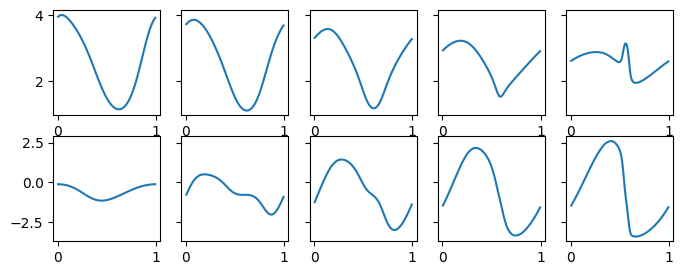

In [3]:
sample_idx = 0
fig, axes = plt.subplots(2, 5, figsize=(8, 3), sharey="row")
for i, axes_row in enumerate(axes):
    for j, ax in enumerate(axes_row):
        ax.plot(dataset_xr.coords["x"], dataset_xr["values"][sample_idx, 10 * j, i])


In [4]:
datadir = Path("../../data/datasets/shallow_water_1d/data/train")
dataset_xr = xr.open_mfdataset(
    sorted(list(datadir.glob("shallow_water_1d_train_grf_seed=*.hdf5"))),
    combine="nested",
    concat_dim="ic",
    engine="h5netcdf",
)

In [5]:
dataset_xr

<xarray.Dataset> Size: 14GB
Dimensions:  (ic: 87684, t: 101, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 14GB dask.array<chunksize=(8726, 101, 2, 100), meta=np.ndarray>
    coeffs   (ic, param) float64 3MB dask.array<chunksize=(8726, 4), meta=np.ndarray>

In [6]:
dataloader = SegmentLoaderBackground(
    dataset_xr, segment_length=21, batch_size=256, batches_per_load=100
)

In [7]:
dataiter = iter(dataloader)


In [8]:
for i in range(520):
    arr = next(dataiter)
    print(i, jnp.linalg.norm(jnp.reshape(arr, shape=(-1,))))

0 1416.9915
1 1441.4264
2 1483.7727
3 1375.5977
4 1372.1052
5 1466.4108
6 1471.0303
7 1521.5704
8 1481.306
9 1409.1384
10 1476.2297
11 1443.0358
12 1459.8445
13 1578.9712
14 1447.079
15 1404.6604
16 1427.3557
17 1472.2307
18 1452.5969
19 1514.001
20 1431.4287
21 1374.0331
22 1433.6866
23 1478.8265
24 1527.5349
25 1532.97
26 1385.5273
27 1405.4805
28 1373.6511
29 1414.347
30 1417.6305
31 1498.1713
32 1394.9393
33 1404.4645
34 1521.4552
35 1491.1792
36 1408.0406
37 1413.5333
38 1521.9225
39 1467.2681
40 1549.9651
41 1484.1084
42 1440.9385
43 1389.732
44 1626.2064
45 1544.8645
46 1500.6887
47 1522.892
48 1579.0575
49 1379.3888
50 1397.8546
51 1465.3423
52 1534.3584
53 1523.3148
54 1443.4279
55 1511.4824
56 1450.582
57 1493.1876
58 1613.8696
59 1426.4031
60 1489.6299
61 1515.2993
62 1636.6335
63 1483.6256
64 1447.1052
65 1363.1486
66 1478.6436
67 1461.2905
68 1453.6971
69 1559.5626
70 1422.741
71 1490.6028
72 1493.9019
73 1487.1432
74 1443.6425
75 1474.2672
76 1448.3873
77 1414.074
78 1434

In [16]:
for j, a in enumerate(arr):
    print(j, jnp.any(jnp.isnan(a)))

0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 False
9 False
10 False
11 False
12 False
13 False
14 False
15 False
16 False
17 False
18 False
19 False
20 False
21 False
22 False
23 False
24 False
25 False
26 False
27 False
28 False
29 False
30 False
31 False
32 False
33 False
34 False
35 False
36 False
37 False
38 False
39 False
40 False
41 False
42 False
43 False
44 False
45 False
46 False
47 False
48 False
49 False
50 False
51 False
52 False
53 False
54 False
55 False
56 False
57 False
58 False
59 False
60 False
61 False
62 False
63 False
64 False
65 False
66 False
67 False
68 False
69 False
70 False
71 False
72 False
73 False
74 False
75 False
76 False
77 False
78 False
79 False
80 False
81 False
82 False
83 False
84 False
85 False
86 False
87 False
88 False
89 False
90 False
91 False
92 False
93 False
94 False
95 False
96 False
97 False
98 False
99 False
100 False
101 False
102 False
103 False
104 False
105 False
106 False
107 False
108 False
109 False
110 False


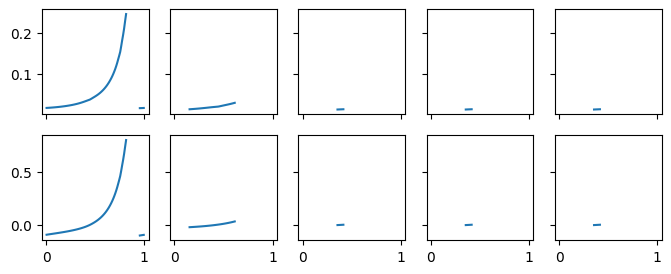

In [20]:
sample_idx = 116
fig, axes = plt.subplots(2, 5, figsize=(8, 3), sharey="row", sharex=True)
for i, axes_row in enumerate(axes):
    for j, ax in enumerate(axes_row):
        ax.plot(dataset_xr.coords["x"], arr[sample_idx, 10 * j, i])


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

Array(True, dtype=bool)

In [62]:
arr = next(dataiter)

In [10]:
arr.dtype.itemsize * arr.size * 50 / 1e9

0.86016

In [53]:
arr.shape

(256, 21, 2, 100)

In [ ]:
import numpy as np


np.all(np.isnan(arr))

np.False_

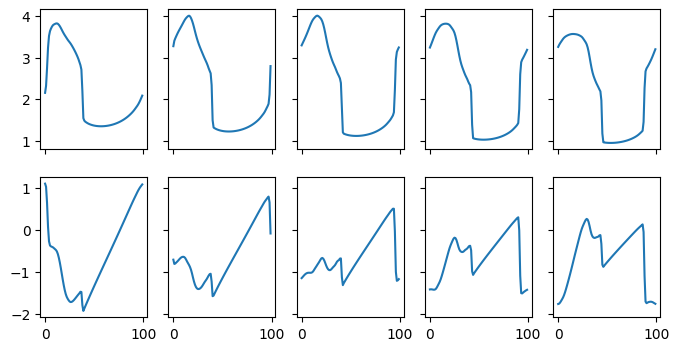

In [68]:
sample_idx = 60
fig, axes = plt.subplots(2, 5, figsize=(8, 4), sharex=True, sharey="row")
for i, ax_row in enumerate(axes):
    for j, ax in enumerate(ax_row):
        ax.plot(arr[sample_idx, 4 * j, i])

In [44]:
dpot = DPOT(
    num_spatial_dims=1,
    in_channels=2,
    out_channels=2,
    in_timesteps=20,
    grid_size=(100,),
    patch_size=(4,),
    embedding_dim=128,
    max_frequency_modes=12,
    fno_depth=10,
    num_blocks=8,
    hidden_dim_patch=512,
    hidden_dim_fno=512,
    hidden_dim_output=512,
    key=jax.random.key(0),
)
print(dpot.num_parameters() / 1e6)

2.295426


In [15]:
hyperfluxfno = HyperFluxFNOLocal(
    num_spatial_dims=1,
    in_channels=2,
    in_timesteps=20,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(100,),
        patch_size=(4,),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    depth=4,
    lift_dim=128,
    stencil_size=(10, 10),
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno.num_parameters() / 1e6)

/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/encoders/utils.py:50: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/nn/structured_linear.py:40: UserWarning: out_features is not divisible by num_blocks. Output vector 
            will be truncated to the requested size.
  warnings.warn("""out_features is not divisible by num_blocks. Output vector


2.77146


In [17]:
disco = DISCO(
    num_spatial_dims=1,
    channels=2,
    embedding_dim=128,
    patch_size=4,
    num_hypernet_blocks=3,
    droppath=0.1,
    num_hypernet_heads=8,
    mlp_hidden_dim=32,
    boundary_condition="periodic",
    opnet_hidden_channels=4,
    opnet_norm_groups=2,
    rtol=1e-4,
    atol=1e-6,
    max_steps=16,
    key=jax.random.key(0),
)
print(disco.num_parameters() / 1e6)

2.154834


In [ ]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "hyperfluxfno"},
)